<a href="https://colab.research.google.com/github/meiladrahmani556/marine-cbm-ml-dissertation/blob/main/Notebook_1_Click/Notebook04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
PROJECT_PATH = "/content/drive/MyDrive/✨CBM Data for Marine System Monitoring & Analysis✨"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

print('Libraries imported successfully')

Libraries imported successfully


In [4]:
from google.colab import files

uploaded = files.upload()

Saving Conditional_Base_Monitoring in Marine_System.csv to Conditional_Base_Monitoring in Marine_System.csv


In [5]:
df = pd.read_csv('Conditional_Base_Monitoring in Marine_System.csv')

df.columns = df.columns.str.strip()
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()
df = df.drop_duplicates()

print('Shape:', df.shape)
df.head()

Shape: (11936, 18)


,Lever position,Ship speed (v),Gas Turbine (GT) shaft torque (GTT) [kN m],GT rate of revolutions (GTn) [rpm],Gas Generator rate of revolutions (GGn) [rpm],Starboard Propeller Torque (Ts) [kN],Port Propeller Torque (Tp) [kN],Hight Pressure (HP) Turbine exit temperature (T48) [C],GT Compressor inlet air temperature (T1) [C],GT Compressor outlet air temperature (T2) [C],HP Turbine exit pressure (P48) [bar],GT Compressor inlet air pressure (P1) [bar],GT Compressor outlet air pressure (P2) [bar],GT exhaust gas pressure (Pexh) [bar],Turbine Injecton Control (TIC) [%],Fuel flow (mf) [kg/s],GT Compressor decay state coefficient,GT Turbine decay state coefficient
0,5.140,15.0,21640.162,1924.358,8516.691,175.324,175.324,706.702,288.0,640.873,2.072,0.998,10.916,1.026,24.960,0.494,0.951,1.000
1,9.300,27.0,72776.229,3560.412,9759.837,645.137,645.137,1060.156,288.0,774.302,4.511,0.998,22.426,1.051,87.741,1.737,0.982,0.997
2,8.206,24.0,50994.673,3087.535,9313.854,438.110,438.110,927.728,288.0,734.474,3.577,0.998,18.412,1.041,60.546,1.199,0.966,0.988
3,5.140,15.0,21626.805,1924.329,8472.097,175.221,175.221,695.477,288.0,633.124,2.086,0.998,11.074,1.027,24.549,0.486,0.989,0.991
5,4.161,12.0,14723.428,1547.467,7790.899,113.778,113.778,644.315,288.0,609.087,1.657,0.998,8.901,1.022,17.334,0.343,0.962,0.988


In [6]:
target_column = 'GT Compressor decay state coefficient'

X = df.drop(columns=[target_column])
y = df[target_column]

print('Features:', X.shape[1])
print('Samples:', X.shape[0])

Features: 17
Samples: 11936


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('Training samples:', X_train.shape[0])
print('Test samples:    ', X_test.shape[0])

Training samples: 9548
Test samples:     2388


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Scaling applied successfully')

Scaling applied successfully


In [9]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

r2_lr   = r2_score(y_test, y_pred_lr)
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print('--- Linear Regression ---')
print('R2:  ', round(r2_lr,   6))
print('MAE: ', round(mae_lr,  6))
print('RMSE:', round(rmse_lr, 6))

--- Linear Regression ---
R2:   0.901415
MAE:  0.00335
RMSE: 0.004677


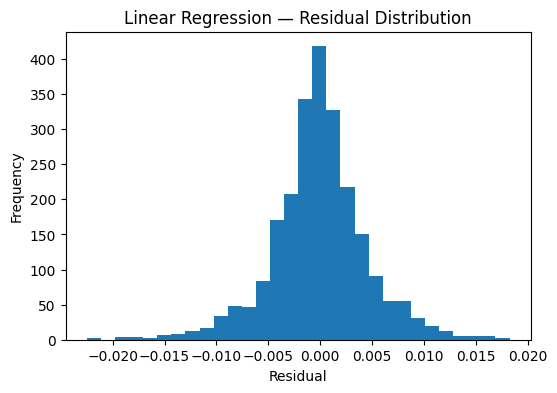

In [10]:
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(6, 4))
plt.hist(residuals_lr, bins=30)
plt.title('Linear Regression — Residual Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

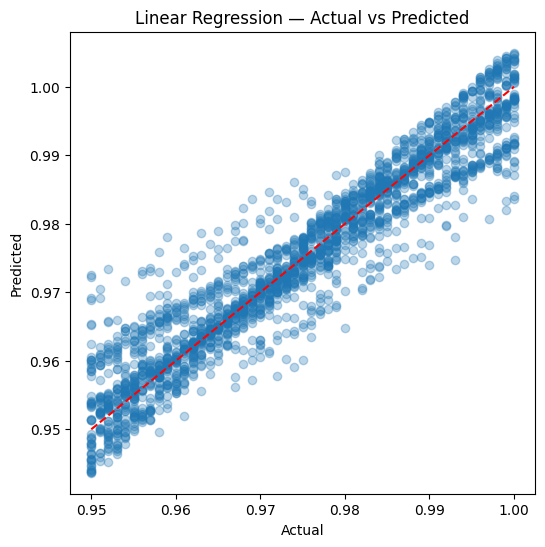

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression — Actual vs Predicted')
plt.show()

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('--- Random Forest (Baseline) ---')
print('R2:  ', round(r2_rf,   6))
print('MAE: ', round(mae_rf,  6))
print('RMSE:', round(rmse_rf, 6))

--- Random Forest (Baseline) ---
R2:   0.998156
MAE:  0.000403
RMSE: 0.00064


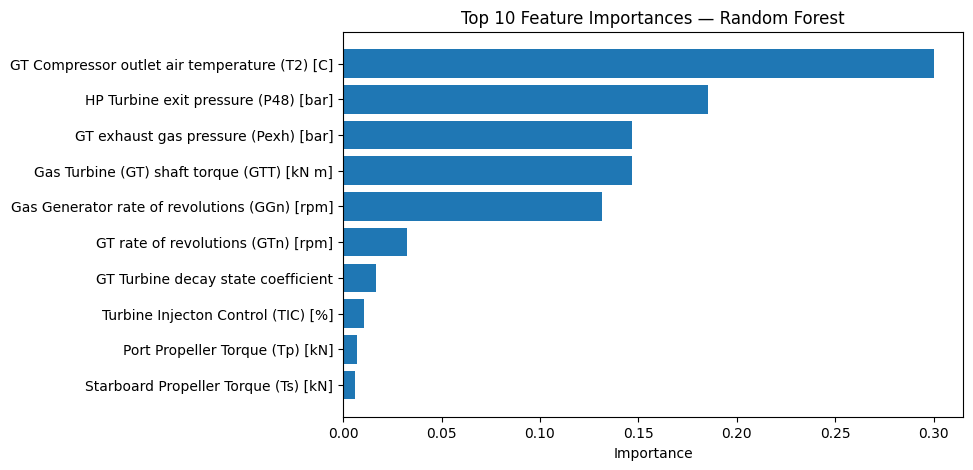

In [13]:
importances = rf_model.feature_importances_
features    = X.columns

importance_df = pd.DataFrame({
    'Feature':    features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(
    importance_df['Feature'][:10],
    importance_df['Importance'][:10]
)
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.show()

In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'R2':    [r2_lr,   r2_rf],
    'MAE':   [mae_lr,  mae_rf],
    'RMSE':  [rmse_lr, rmse_rf]
})

print(results.to_string(index=False))

            Model       R2      MAE     RMSE
Linear Regression 0.901415 0.003350 0.004677
    Random Forest 0.998156 0.000403 0.000640


In [15]:
import os

os.makedirs(f'{PROJECT_PATH}/models', exist_ok=True)

joblib.dump(lr_model, f'{PROJECT_PATH}/models/linear_regression.pkl')
joblib.dump(rf_model, f'{PROJECT_PATH}/models/random_forest_baseline.pkl')

print('Models saved to Google Drive')

Models saved to Google Drive
